In [5]:
%run ldpc_encoder.ipynb
%run bf_decoder.ipynb

N=6, K=4, z=2  ->  base matrix B (shape (1, 3)):
[[1 1 1]] 

Parity-check matrix H (lifted from base matrix):
[[0 1 0 1 0 1]
 [1 0 1 0 1 0]] 

Systematic parity-check matrix H_sys = [P | I]:
[[1 0 1 0 1 0]
 [0 1 0 1 0 1]] 

Generator matrix G = [I | P^T]:
[[1 0 0 0 1 0]
 [0 1 0 0 0 1]
 [0 0 1 0 1 0]
 [0 0 0 1 0 1]] 

Message u = [0, 1, 1, 1]
Codeword v = [0 1 1 1 1 0]

BPSK symbols x        = [ 1. -1. -1. -1. -1.  1.]
Noise std (sigma)     = 0.6131  (Eb/N0 = 3.0 dB, rate = 0.6666666666666666)
Received samples r    = [ 0.9862 -0.84   -0.6501 -0.8049 -0.3621  0.5634]

Hard-decision bits    = [0 1 1 1 1 0]
(compare to original codeword v = [0 1 1 1 1 0])
Verifying all 16 possible 4-bit messages give valid codewords (H.v^T = 0):
  u=[0, 0, 0, 0] -> v=[0 0 0 0 0 0]  syndrome=[0 0]  OK
  u=[0, 0, 0, 1] -> v=[0 0 0 1 0 1]  syndrome=[0 0]  OK
  u=[0, 0, 1, 0] -> v=[0 0 1 0 1 0]  syndrome=[0 0]  OK
  u=[0, 0, 1, 1] -> v=[0 0 1 1 1 1]  syndrome=[0 0]  OK
  u=[0, 1, 0, 0] -> v=[0 1 0 0 0 1]  synd

In [10]:
import math
import numpy as np
import matplotlib.pyplot as plt

#### Monte Carlo BER simulation function

In [6]:
def simulate_ber(N, K, z, ebno_db_list, max_trials=20000, target_bit_errors=100,
                  decoder_rule="max", tie_break="random", max_iterations=50,
                  base_seed=0, verbose=True):
    """
    Monte Carlo simulation of: encode -> BPSK -> AWGN -> Bit-Flipping decode,
    sweeping over a list of Eb/N0 (dB) values.
 
    For each Eb/N0 point, trials keep running until EITHER:
      - `target_bit_errors` bit errors have been observed (ensures the BER
        estimate at that point is statistically meaningful), OR
      - `max_trials` trials have been run (safety cap -- important at high
        Eb/N0, where errors become rare and could otherwise require an
        impractical number of trials).
 
    Returns a dict of per-point results: ebno_db, ber, fer (frame/codeword
    error rate), num_trials, num_bit_errors.
    """
    # Build the code once (shared across all Eb/N0 points)
    B = generate_base_matrix(N, K, z, seed=base_seed)
    H = build_parity_check_matrix(B, z)
    H_sys, _ = to_systematic_form(H)
    G = derive_generator_matrix(H_sys, K)
    R = K / N
 
    results = {"ebno_db": [], "ber": [], "fer": [], "num_trials": [], "num_bit_errors": []}
 
    for point_idx, ebno_db in enumerate(ebno_db_list):
        sigma = awgn_noise_std(ebno_db, R)
        rng = np.random.default_rng(base_seed + point_idx + 1)   # independent stream per point
 
        total_bits = 0
        bit_errors = 0
        frame_errors = 0
        trials_run = 0
 
        while trials_run < max_trials and bit_errors < target_bit_errors:
            u = rng.integers(0, 2, size=K)
            v = encode(u, G)
            x = bpsk_modulate(v)
 
            # Draw AWGN directly with this point's rng (reproducible, and
            # avoids creating a brand-new Generator on every single trial).
            noise = rng.normal(0.0, sigma, size=x.shape)
            y = x + noise
 
            z_hat, _, _ = bit_flipping_decode(
                y, H_sys, max_iterations=max_iterations,
                rule=decoder_rule, tie_break=tie_break, rng=rng
            )
            u_hat = extract_message_bits(z_hat, K)
 
            errors_this_trial = int(np.sum(u_hat != u))
            bit_errors += errors_this_trial
            total_bits += K
            frame_errors += 1 if errors_this_trial > 0 else 0
            trials_run += 1
 
        ber = bit_errors / total_bits
        fer = frame_errors / trials_run
 
        results["ebno_db"].append(ebno_db)
        results["ber"].append(ber)
        results["fer"].append(fer)
        results["num_trials"].append(trials_run)
        results["num_bit_errors"].append(bit_errors)
 
        if verbose:
            flag = "  (hit max_trials, few/no errors seen)" if bit_errors < target_bit_errors else ""
            print(f"Eb/N0={ebno_db:5.1f} dB | trials={trials_run:7d} | "
                  f"bit errors={bit_errors:5d} | BER={ber:.3e} | FER={fer:.3e}{flag}")
 
    return results

#### Theoretical uncoded BPSK BER, for comparison

In [7]:
def uncoded_bpsk_ber(ebno_db_list):
    """Theoretical BER of uncoded BPSK over AWGN: BER = 0.5*erfc(sqrt(Eb/N0))."""
    return [0.5 * math.erfc(math.sqrt(10 ** (e / 10))) for e in ebno_db_list]

In [8]:
N = 6
K = 3
z_lift = 3
ebno_db_list = list(range(0, 9))    # 0 to 8 dB
 
results = simulate_ber(
    N, K, z_lift, ebno_db_list,
    max_trials=20000, target_bit_errors=100,
    decoder_rule="max", tie_break="random", max_iterations=50,
    base_seed=0,
)

Eb/N0=  0.0 dB | trials=    216 | bit errors=  100 | BER=1.543e-01 | FER=3.843e-01
Eb/N0=  1.0 dB | trials=    260 | bit errors=  100 | BER=1.282e-01 | FER=3.538e-01
Eb/N0=  2.0 dB | trials=    322 | bit errors=  100 | BER=1.035e-01 | FER=2.671e-01
Eb/N0=  3.0 dB | trials=    478 | bit errors=  100 | BER=6.974e-02 | FER=1.862e-01
Eb/N0=  4.0 dB | trials=    539 | bit errors=  100 | BER=6.184e-02 | FER=1.763e-01
Eb/N0=  5.0 dB | trials=    848 | bit errors=  100 | BER=3.931e-02 | FER=1.108e-01
Eb/N0=  6.0 dB | trials=   1336 | bit errors=  100 | BER=2.495e-02 | FER=7.335e-02
Eb/N0=  7.0 dB | trials=   3006 | bit errors=  100 | BER=1.109e-02 | FER=3.260e-02
Eb/N0=  8.0 dB | trials=   6199 | bit errors=  100 | BER=5.377e-03 | FER=1.613e-02


#### Plot BER vs Eb/N0

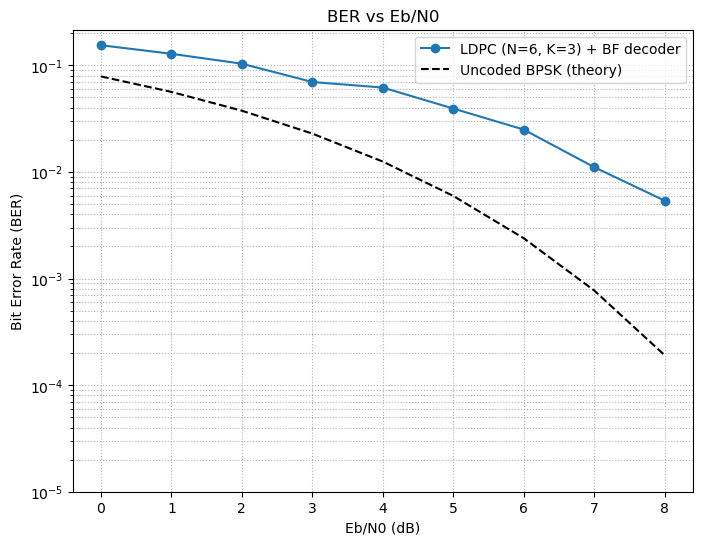

In [11]:
uncoded = uncoded_bpsk_ber(ebno_db_list)
 
plt.figure(figsize=(8, 6))
plt.semilogy(results["ebno_db"], results["ber"], "o-", label=f"LDPC (N={N}, K={K}) + BF decoder")
plt.semilogy(ebno_db_list, uncoded, "k--", label="Uncoded BPSK (theory)")
plt.xlabel("Eb/N0 (dB)")
plt.ylabel("Bit Error Rate (BER)")
plt.title("BER vs Eb/N0")
plt.grid(True, which="both", linestyle=":")
plt.legend()
plt.ylim(bottom=1e-5)
plt.show()